## Control 2

Juan Pablo Cárdenas - Vicente Mieres

In [3]:
# Funciones

import dask.array as da
import numpy as np

def simular_visibilidades():
    # 1. Definir dimensiones y chunks
    Nu, Nv, T = 1000, 1000, 100
    chunks = (200, 200, 20)
    
    # 2. Crear datos sintéticos complejos (Lazy evaluation)
    # Dask no genera los números todavía, solo crea el grafo de tareas.
    # Usamos random normal para parte real e imaginaria.
    real_part = da.random.normal(0, 1, size=(Nu, Nv, T), chunks=chunks)
    imag_part = da.random.normal(0, 1, size=(Nu, Nv, T), chunks=chunks)
    
    # Visibilidades griddeadas
    visibilidades = real_part + 1j * imag_part
    
    print(f"Array de Dask creado: {visibilidades}")
    print(f"Tamaño en memoria (si fuera numpy): {visibilidades.nbytes / 1e9:.2f} GB")

    # 3. Calcular el promedio temporal (eje 2, que corresponde a T)
    # Esto reduce la dimensión de (1000, 1000, 100) a (1000, 1000)
    promedio_temporal = visibilidades.mean(axis=2)
    
    # 4. Ejecutar el cómputo (Trigger)
    # Aquí es donde Dask realmente trabaja.
    resultado = promedio_temporal.compute()
    
    return resultado, visibilidades

# Ejecución
resultado_a , vis= simular_visibilidades()
print(f"Forma del resultado final: {resultado_a.shape}") # Debería ser (1000, 1000)

Array de Dask creado: dask.array<add, shape=(1000, 1000, 100), dtype=complex128, chunksize=(200, 200, 20), chunktype=numpy.ndarray>
Tamaño en memoria (si fuera numpy): 1.60 GB
Forma del resultado final: (1000, 1000)


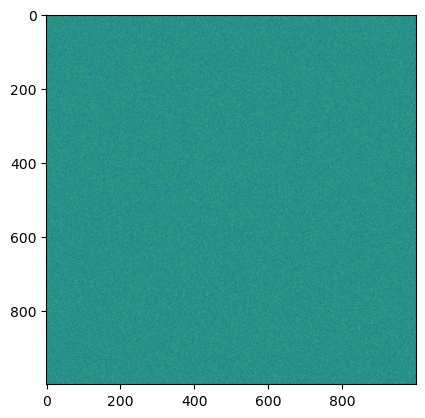

In [16]:
import matplotlib.pyplot as plt
plt.imshow(resultado_a.real)

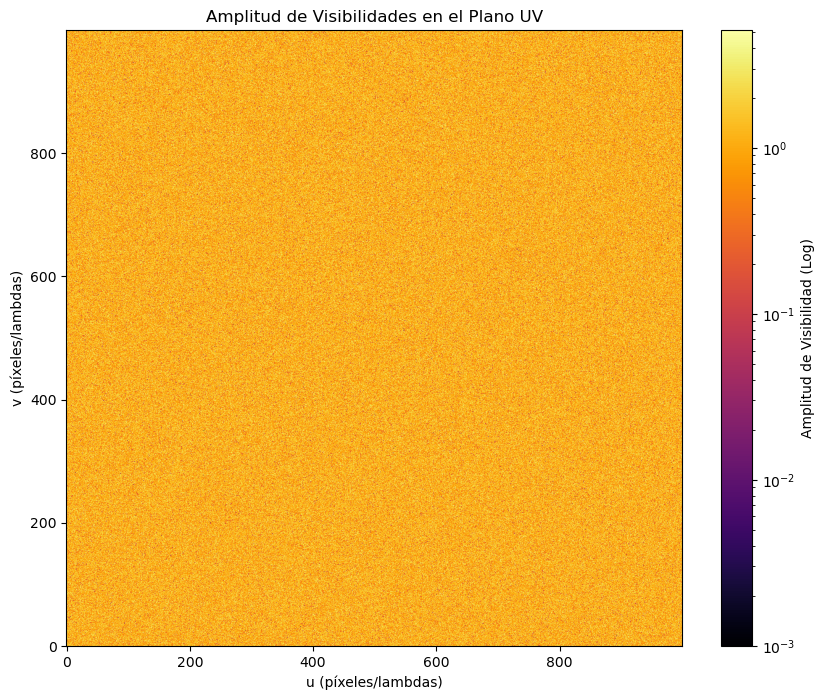

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Asumimos que 'resultado_a' es tu array de numpy (1000x1000) complejo
# resultado_a = dask_array.compute() 

def plot_plano_uv(vis_grid):
    plt.figure(figsize=(10, 8))
    
    # Calculamos la amplitud (magnitud) de los números complejos
    amplitud = np.abs(vis_grid)
    
    # Usamos LogNorm para ver detalles tanto en valores altos como bajos
    # extent define los límites de los ejes (ajusta según tu simulación real)
    plt.imshow(amplitud, 
               cmap='inferno', 
               norm=LogNorm(vmin=amplitud.min(), vmax=amplitud.max()),
               origin='lower') # Pone el (0,0) abajo a la izquierda
            #    extent=[-500, 500, -500, 500]) # Ejes en píxeles o lambdas
    
    plt.colorbar(label='Amplitud de Visibilidad (Log)')
    plt.title("Amplitud de Visibilidades en el Plano UV")
    plt.xlabel("u (píxeles/lambdas)")
    plt.ylabel("v (píxeles/lambdas)")
    plt.grid(False) # Grid suele molestar en heatmaps
    plt.show()

# Ejecutar
plot_plano_uv(vis[:,:,0])
